
COURSE: SIG720 MACHINE LEARNING

Title: TASK8

NAME: OLALEYE, Samson

STUDENT ID: 226173059

Email_address: solaleye562@gmail.com

Part 1: Problem Definition and Data Collection

In [1]:
import pandas as pd

# 1. Loading the dataset. 
df = pd.read_excel("C:/Users/SAMSON/Desktop/desktop/MDS_Deakin University/Machine Learning/Week 8/realestate-com-auhouse-sales1.xlsx")

In [2]:
df.head()

,S/No.,Agent,Address,Suburb,Price (AUD),Size in sq meter,Bed room,Shower,Car spaces,Date Sold,Nature
0,1,RayWhite,"1708/60 Bathurst Street, Sydney",Sydney,880000,56.0,1,1,0,2025-11-19,Apartment
1,2,LJ Hooker,"74/267 Castlereagh Street, Sydney",Sydney,1084000,93.0,2,2,1,2025-11-20,Apartment
2,3,Morton,"91/336-346 Sussex Street, Sydney",Sydney,762000,76.0,2,1,1,2025-11-20,Apartment
3,4,Ayre,"520/298 Sussex Street, Sydney",Sydney,730000,63.0,1,1,1,2025-11-26,Apartment
4,5,Ayre,"1503/281 Elizabeth Street, Sydney",Sydney,1977000,100.0,2,2,1,2025-11-26,Apartment


All the top 5 rows are from Sydney suburb because the properties were sold in November 2025. The datasets were recorded according to date taht the property was sold.

In [3]:
df.tail()

,S/No.,Agent,Address,Suburb,Price (AUD),Size in sq meter,Bed room,Shower,Car spaces,Date Sold,Nature
164,117,Harcourts,"57 Walters Road, Blacktown",Blacktown,1221000,835.0,3,1,1,2026-08-08,House
165,118,RayWhite,"41 Burrell Parade, Blacktown",Blacktown,960000,556.0,3,1,2,2026-08-11,Apartment
166,119,Starrpartners,"12 Glamorgan Street, Blacktown",Blacktown,1030000,556.0,3,1,1,2026-08-11,Apartment
167,120,Raine & Home,6 Erifield Street,Marrickville,2321000,252.9,3,1,1,2026-08-05,House
168,121,Raine & Home,27/176 Marrickville Road,Marrickville,2600000,380.0,3,2,4,2026-08-05,Apartment


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   S/No.             169 non-null    int64         
 1   Agent             169 non-null    object        
 2   Address           169 non-null    object        
 3   Suburb            169 non-null    object        
 4   Price (AUD)       169 non-null    int64         
 5   Size in sq meter  169 non-null    float64       
 6   Bed room          169 non-null    int64         
 7   Shower            169 non-null    int64         
 8   Car spaces        169 non-null    int64         
 9   Date Sold         169 non-null    datetime64[ns]
 10  Nature            169 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(4)
memory usage: 14.7+ KB


COMMENT:
There are 169 rows of dataset. Among the dataset are five integers, four objects, one float and one datetime. 

In [5]:
df.describe()

,S/No.,Price (AUD),Size in sq meter,Bed room,Shower,Car spaces,Date Sold
count,169.000000,1.690000e+02,169.000000,169.000000,169.000000,169.000000,169
mean,50.633136,1.620029e+06,317.715030,2.816568,1.721893,1.355030,2026-05-27 04:32:39.763313664
min,1.000000,4.100000e+05,30.000000,0.000000,1.000000,0.000000,2025-11-19 00:00:00
25%,22.000000,9.500000e+05,96.000000,2.000000,1.000000,1.000000,2026-05-01 00:00:00
50%,43.000000,1.200000e+06,196.000000,3.000000,2.000000,1.000000,2026-06-15 00:00:00
75%,79.000000,1.960000e+06,556.000000,3.000000,2.000000,2.000000,2026-07-17 00:00:00
max,121.000000,9.880000e+06,2039.000000,24.000000,15.000000,12.000000,2026-08-11 00:00:00
std,34.728304,1.243505e+06,289.015085,2.025600,1.243863,1.381636,NaN


COMMENT:
The highest price of the dataset is $9,880,000 while the lowest price is $410,000. The biggest property size is 2,039 sq. meters while the smallest is 30 sq. meters.

Part 2: Data Understanding and Feature Engineering


1. Exploring the Distribution of Housing Prices
   

count    1.690000e+02
mean     1.620029e+06
std      1.243505e+06
min      4.100000e+05
25%      9.500000e+05
50%      1.200000e+06
75%      1.960000e+06
max      9.880000e+06
Name: Price (AUD), dtype: float64


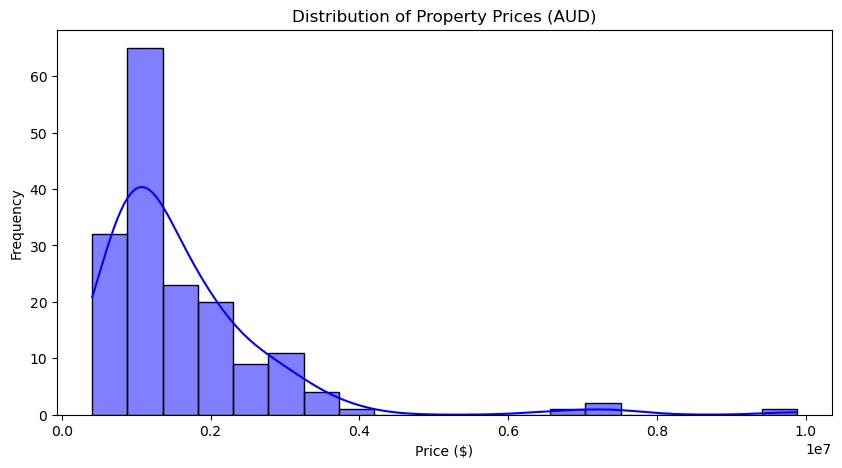

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Summary statistics for a quick numeric overview
print(df['Price (AUD)'].describe())

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Price (AUD)'], kde=True, color='blue', bins=20)
plt.title('Distribution of Property Prices (AUD)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()


COMMENT: The distribution of the property prices is skewed to the right as a result of some outliers.


2. Investigating Differences Between Suburbs
   

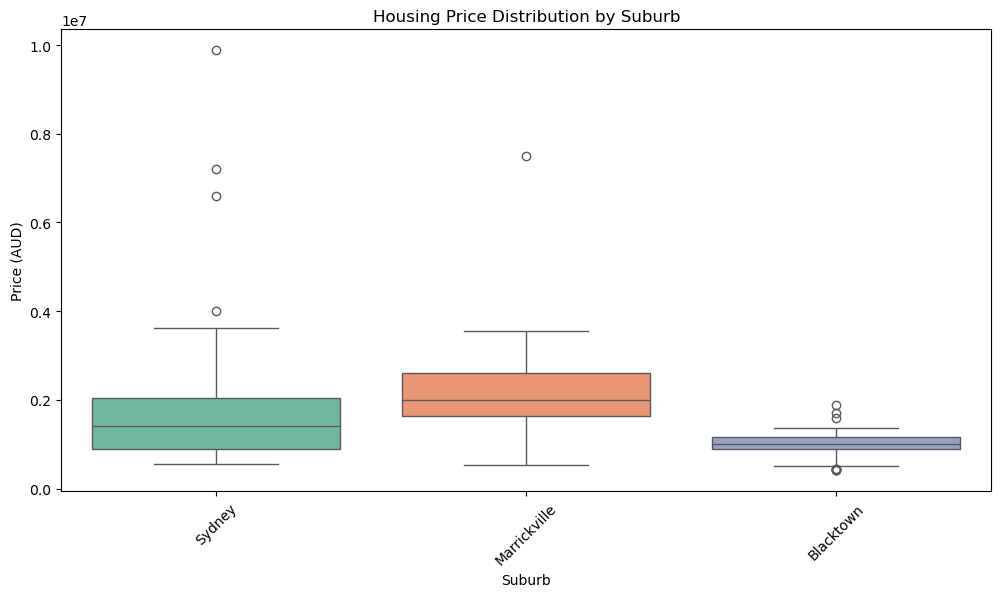

In [7]:
# Updated, future-proof boxplot code
plt.figure(figsize=(12, 6))
sns.boxplot(x='Suburb', y='Price (AUD)', data=df, hue='Suburb', palette='Set2', legend=False)
plt.title('Housing Price Distribution by Suburb')
plt.xticks(rotation=45)
plt.ylabel('Price (AUD)')
plt.show()

COMMENT: The median property price of Marrickville suburb is the highest of the three while Sydney suburb has more outliers than the other two. Blacktown has the lowest price distribution and the lowest median of the three. 


3. Examine Trends Over Time
   

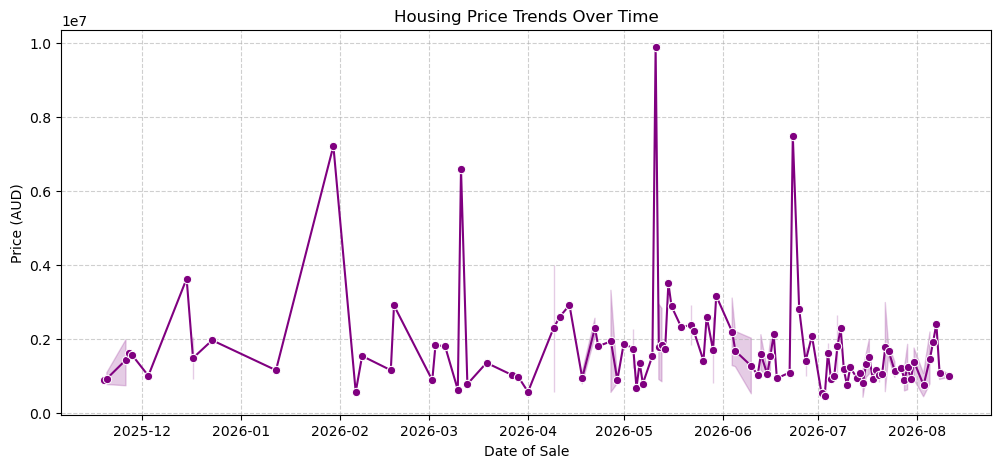

In [8]:
# Convert Date Sold column to datetime structure
df['Date Sold'] = pd.to_datetime(df['Date Sold'])

# Sort by date to maintain chronological order
df = df.sort_values('Date Sold')

# Plot structural price movements over time
plt.figure(figsize=(12, 5))
sns.lineplot(x='Date Sold', y='Price (AUD)', data=df, marker='o', color='purple')
plt.title('Housing Price Trends Over Time')
plt.xlabel('Date of Sale')
plt.ylabel('Price (AUD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


COMMENT
Week 1 in the month of May 2026 recorded the highest property price. In line with earlier observation, because more properties in Blacktown were sold in August 2026, the graph reflected this by having more clustered graph.   



4. Identify Unusual Observations and Potential Outliers
   

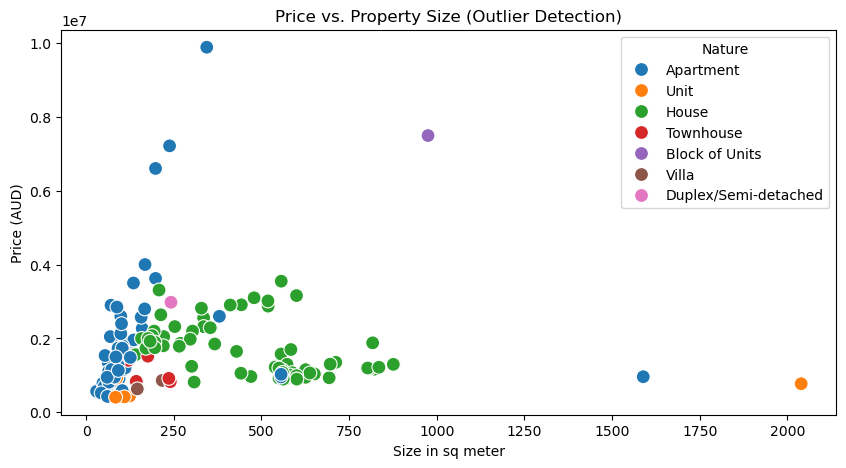

Potential Outliers Based on Price:
    S/No.               Agent                        Address        Suburb  \
9      10                Ayre  904/23 Shelley Street, Sydney        Sydney   
14     15            RayWhite             21/155 Kent Street        Sydney   
23     24      Black Diamondz        51/155 Marquarie Street        Sydney   
30     31            RayWhite       3104/116 Bathurst Street        Sydney   
49      2                Ayre       5403/101 Bathurst Street        Sydney   
50      3      Adrian William               20 Porter Avenue  Marrickville   
57     10                Ayre       7202/117 Bathurst Street        Sydney   
94     47  Home Estate Agents               25 George Street  Marrickville   

    Price (AUD)  Size in sq meter  Bed room  Shower  Car spaces  Date Sold  \
9       3625000             198.0         3       3           2 2025-12-15   
14      7211000             238.0         3       3           2 2026-01-30   
23      6600000             

In [9]:
# Visual Method: Scatter plot to find properties with unusual price-to-size ratios
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Size in sq meter', y='Price (AUD)', hue='Nature', data=df, s=100)
plt.title('Price vs. Property Size (Outlier Detection)')
plt.show()

# Mathematical Method: Isolate rows beyond 1.5 * IQR
Q1 = df['Price (AUD)'].quantile(0.25)
Q3 = df['Price (AUD)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price (AUD)'] < lower_bound) | (df['Price (AUD)'] > upper_bound)]
print("Potential Outliers Based on Price:")
print(outliers)


COMMENT:
Apartment, Block of Units and Townhouse recorded the notable outliers of the dataset.


 The three variables that will have the strongest influence on housing prices are Size in sq meter, Bed room, and Suburb
 

In [11]:
# 1. Test Physical Factors (Size vs Price)

# Force pandas to show normal numbers with two decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Let's re-run the suburb summary
print(df.groupby('Suburb')['Price (AUD)'].mean())

size_correlation = df['Price (AUD)'].corr(df['Size in sq meter'])
print(f"Correlation between Size and Price: {size_correlation:.2f}")

# 2. Test Utility Factors (Bedrooms vs Price)
print("\nAverage Price by Bedroom Count:")
print(df.groupby('Bed room')['Price (AUD)'].mean())

# 3. Test Locational Factors (Suburb vs Price)
print("\nAverage Price by Suburb:")
print(df.groupby('Suburb')['Price (AUD)'].mean())


Suburb
Blacktown       995252.83
Marrickville   2112769.04
Sydney         1874444.44
Name: Price (AUD), dtype: float64
Correlation between Size and Price: 0.02

Average Price by Bedroom Count:
Bed room
0     562500.00
1    1066083.33
2    1282425.53
3    1784081.77
4    2319597.20
5    1265000.00
6    1432750.00
7    1700000.00
24   7490000.00
Name: Price (AUD), dtype: float64

Average Price by Suburb:
Suburb
Blacktown       995252.83
Marrickville   2112769.04
Sydney         1874444.44
Name: Price (AUD), dtype: float64


From the above results, the three variables: Size in sq meter, Bed room, and Suburb confirms their importance in influencing the property valuation. Blacktown has the lowest average price among the three suburbs. Also, the price of the property increases as the number of the bedroom increases. 

Part 3: Model Development and Evaluation

Developing three regression models that represent different modelling approaches

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. To Prepare Data & Handle Categorical Variables (Suburb, Nature)
df_encoded = pd.get_dummies(df, columns=['Suburb', 'Nature'], drop_first=True)

# Define Features (X) and Target (y)
features = ['Size in sq meter', 'Bed room', 'Shower', 'Car spaces'] + [col for col in df_encoded.columns if 'Suburb_' in col or 'Nature_' in col]
X = df_encoded[features]
y = df_encoded['Price (AUD)']

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# APPROACH 1: Multiple Linear Regression
# ==========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# ==========================================
# APPROACH 2: Ridge Regression (Regularized)
# ==========================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)

# ==========================================
# APPROACH 3: Random Forest (Non-Linear)
# ==========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# ==========================================
# EVALUATION & COMPARISON
# ==========================================
models = {
    "Linear Regression": lr_preds,
    "Ridge Regression": ridge_preds,
    "Random Forest": rf_preds
}

print(f"{'Model':<20} | {'MAE (Mean Abs Error)':<20} | {'R² Score':<10}")
print("-" * 58)
for name, preds in models.items():
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name:<20} | ${mae:<19,.2f} | {r2:<10.4f}")


Model                | MAE (Mean Abs Error) | R² Score  
----------------------------------------------------------
Linear Regression    | $531,949.05          | 0.3304    
Ridge Regression     | $485,711.68          | 0.4326    
Random Forest        | $325,055.23          | 0.5825    



 Let's Extract Weights and Importances
 

In [13]:
import pandas as pd
import numpy as np

# 1. Extract Coefficients from Linear and Ridge Regression
# (These represent direct dollar changes per unit increase)
linear_coefs = lr_model.coef_
ridge_coefs = ridge_model.coef_

# 2. Extract Relative Feature Importance from Random Forest
# (These are percentages/fractions summing to 1.0 showing predictive weight)
rf_importances = rf_model.feature_importances_

# 3. Consolidate into a clean, comparative DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Linear Regression Coef ($)': linear_coefs,
    'Ridge Regression Coef ($)': ridge_coefs,
    'Random Forest Importance': rf_importances
})

# Format for clean readability
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(importance_df.sort_values(by='Random Forest Importance', ascending=False))


                        Feature  Linear Regression Coef ($)  \
0              Size in sq meter                      786.31   
2                        Shower                   518054.90   
5                 Suburb_Sydney                  1826375.10   
4           Suburb_Marrickville                  1610909.00   
1                      Bed room                   212319.28   
3                    Car spaces                   165888.46   
8                  Nature_House                    75720.05   
6         Nature_Block of Units                 -8324093.77   
10                  Nature_Unit                   109915.55   
7   Nature_Duplex/Semi-detached                   195977.07   
9              Nature_Townhouse                  -159216.88   
11                 Nature_Villa                   471186.38   

    Ridge Regression Coef ($)  Random Forest Importance  
0                      557.42                      0.29  
2                   414363.65                      0.26  
5     

In [ ]:
COMMENT:
Size in sq. meter is influential in the determination of property value from the Random Forest report.
The feature importance graph will show it better.    

VISUALIZING THE WEIGHTS OR FEATURE IMPORTANCE

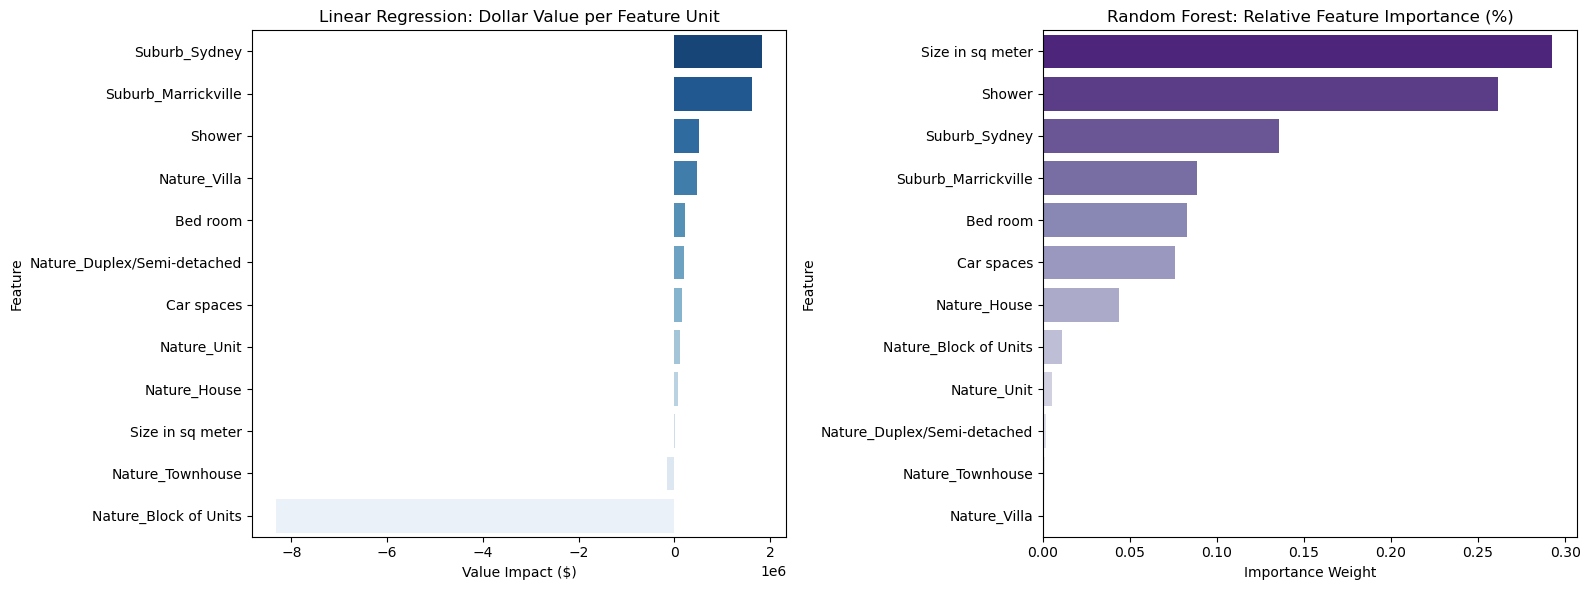

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Le's set up side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Linear Coefficients
sns.barplot(x='Linear Regression Coef ($)', y='Feature', data=importance_df.sort_values(by='Linear Regression Coef ($)', ascending=False), ax=axes[0], palette='Blues_r', hue='Feature', legend=False)
axes[0].set_title('Linear Regression: Dollar Value per Feature Unit')
axes[0].set_xlabel('Value Impact ($)')

# Plot Random Forest Importances
sns.barplot(x='Random Forest Importance', y='Feature', data=importance_df.sort_values(by='Random Forest Importance', ascending=False), ax=axes[1], palette='Purples_r', hue='Feature', legend=False)
axes[1].set_title('Random Forest: Relative Feature Importance (%)')
axes[1].set_xlabel('Importance Weight')

plt.tight_layout()
plt.show()


From the feature importance shown above, using the Random Forest model, the size in sq. meter of the property ranks first as a major influence on the price of a property. For the Linear Regression, the suburb ranks most among the features especially Sydney suburb. This aligns with the knowledge of the suburbs, with Sidney ranking first, followed by Marrickville and Blacktown ranks third.  


K-Fold Cross-Validation:
To rigorously test how these models adapt across different subsets of the property data, we will implement 5-Fold Cross-Validation. This splits the dataset into five distinct rotations, ensuring every property (from premium Sydney CBD apartments to more affordable Blacktown dwellings) is used for both training and testing.


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Preprocessing & Alignment (Handle categorical text variables)
df_encoded = pd.get_dummies(df, columns=['Suburb', 'Nature'], drop_first=True)

# Map features (X) and target (y)
features = ['Size in sq meter', 'Bed room', 'Shower', 'Car spaces'] + \
           [col for col in df_encoded.columns if 'Suburb_' in col or 'Nature_' in col]
X = df_encoded[features]
y = df_encoded['Price (AUD)']

# 2. Configure 5-Fold Cross-Validation Strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define standard regression evaluation metrics
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# Initialize our 3 diverse modeling approaches
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 3. Execute and Consolidate CV Performance
cv_results_summary = []

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=kf, scoring=scoring)
    
    # Invert negative metrics back to standard absolute values
    mean_rmse = -np.mean(scores['test_rmse'])
    mean_mae = -np.mean(scores['test_mae'])
    mean_r2 = np.mean(scores['test_r2'])
    
    # Track variance across folds to judge structural stability
    std_r2 = np.std(scores['test_r2'])
    
    cv_results_summary.append({
        "Model": name,
        "Mean RMSE ($)": mean_rmse,
        "Mean MAE ($)": mean_mae,
        "Mean R²": mean_r2,
        "R² Std Dev": std_r2
    })

# Display formatted numerical breakdown
cv_df = pd.DataFrame(cv_results_summary)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print(cv_df.to_string(index=False))


            Model  Mean RMSE ($)  Mean MAE ($)  Mean R²  R² Std Dev
Linear Regression    1025915.671    582662.932    0.278       0.206
 Ridge Regression    1011409.734    554082.955    0.312       0.220
    Random Forest     718415.449    383900.402    0.624       0.064


COMMENTS: Random Forest delivers the best result with the lowest error figure.


K-Fold MAPE Evaluation. At this stage I incorporated MAPE into the 5 K-Fold Cross Validation computed above.


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 1. Align features and target
df_encoded = pd.get_dummies(df, columns=['Suburb', 'Nature'], drop_first=True)
features = ['Size in sq meter', 'Bed room', 'Shower', 'Car spaces'] + \
           [col for col in df_encoded.columns if 'Suburb_' in col or 'Nature_' in col]
X = df_encoded[features]
y = df_encoded['Price (AUD)']

# 2. Setup 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Data containers to hold out-of-fold predictions
df_results = df.copy()
df_results['Linear_Pred'] = 0.0
df_results['Ridge_Pred'] = 0.0
df_results['RF_Pred'] = 0.0

# 3. Generate cross-validated predictions
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train and predict for each model approach
    lr = LinearRegression().fit(X_train, y_train)
    df_results.loc[test_idx, 'Linear_Pred'] = lr.predict(X_test)
    
    ridge = Ridge(alpha=1.0).fit(X_train, y_train)
    df_results.loc[test_idx, 'Ridge_Pred'] = ridge.predict(X_test)
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
    df_results.loc[test_idx, 'RF_Pred'] = rf.predict(X_test)

# ===================================================
# 4. CRITICAL ANALYSIS: Global vs. Suburb-Specific MAPE
# ===================================================
print("====== GLOBAL MODEL MAPE RESULTS =======")
for model_name, pred_col in [("Linear Regression", "Linear_Pred"), 
                             ("Ridge Regression", "Ridge_Pred"), 
                             ("Random Forest", "RF_Pred")]:
    global_mape = mean_absolute_percentage_error(df_results['Price (AUD)'], df_results[pred_col]) * 100
    print(f"{model_name:<20} Global MAPE: {global_mape:.2f}%")

print("\n====== SUBURB-SPECIFIC MAPE BREAKDOWN =======")
# Calculate percentage errors independently per suburb to isolate the Blacktown effect
suburb_mape_summary = []
for suburb in df_results['Suburb'].unique():
    suburb_mask = df_results['Suburb'] == suburb
    suburb_df = df_results[suburb_mask]
    
    suburb_mape_summary.append({
        'Suburb': suburb,
        'Linear MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['Linear_Pred']) * 100,
        'Ridge MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['Ridge_Pred']) * 100,
        'RF MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['RF_Pred']) * 100
    })

print(pd.DataFrame(suburb_mape_summary).to_string(index=False))


====== GLOBAL MODEL MAPE RESULTS =======
Linear Regression    Global MAPE: 49.81%
Ridge Regression     Global MAPE: 46.05%
Random Forest        Global MAPE: 36.19%

====== SUBURB-SPECIFIC MAPE BREAKDOWN =======
      Suburb  Linear MAPE (%)  Ridge MAPE (%)  RF MAPE (%)
      Sydney           55.858          57.752       36.950
Marrickville           32.050          34.011       24.336
   Blacktown           59.287          45.962       45.327


COMMENTS:
The Linear MAPE for Blacktown spike significantly higher than the other suburbs, confirming that a single blanket linear equation is structurally unfair to lower-priced areas. 


Part 4: Investigating Prediction Failures


NOTE:
To address the prediction error, like in this case, using a Logarithmic Transformation on the target variable (Price (AUD)) is one of the most powerful feature engineering techniques for real estate data. Let's see the outcome the assessment. 


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 1. Align features and isolate target
df_encoded = pd.get_dummies(df, columns=['Suburb', 'Nature'], drop_first=True)
features = ['Size in sq meter', 'Bed room', 'Shower', 'Car spaces'] + \
           [col for col in df_encoded.columns if 'Suburb_' in col or 'Nature_' in col]
X = df_encoded[features]

# Target variable is now transformed to a logarithmic scale
y_log = np.log1p(df_encoded['Price (AUD)'])

# 2. Setup 5-Fold Cross Validation Structure
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Data containers to hold out-of-fold natural currency predictions
df_results = df.copy()
df_results['Linear_Log_Pred'] = 0.0
df_results['Ridge_Log_Pred'] = 0.0
df_results['RF_Log_Pred'] = 0.0

# 3. Generate cross-validated predictions on log data
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_log.iloc[train_idx], y_log.iloc[test_idx]
    
    # Train models on LOG target and predict on LOG scale
    lr = LinearRegression().fit(X_train, y_train)
    lr_pred_log = lr.predict(X_test)
    
    ridge = Ridge(alpha=1.0).fit(X_train, y_train)
    ridge_pred_log = ridge.predict(X_test)
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
    rf_pred_log = rf.predict(X_test)
    
    # CRITICAL STEP: Reverse the logarithm using expm1() to return to raw AUD dollars
    df_results.loc[test_idx, 'Linear_Log_Pred'] = np.expm1(lr_pred_log)
    df_results.loc[test_idx, 'Ridge_Log_Pred'] = np.expm1(ridge_pred_log)
    df_results.loc[test_idx, 'RF_Log_Pred'] = np.expm1(rf_pred_log)

# ===================================================
# 4. EVALUATION: Compare New Log-Optimized MAPEs
# ===================================================
print("====== NEW LOG-TRANSFORMED GLOBAL MAPE =======")
for model_name, pred_col in [("Linear Regression (Log)", "Linear_Log_Pred"), 
                             ("Ridge Regression (Log)", "Ridge_Log_Pred"), 
                             ("Random Forest (Log)", "RF_Log_Pred")]:
    global_mape = mean_absolute_percentage_error(df_results['Price (AUD)'], df_results[pred_col]) * 100
    print(f"{model_name:<26} Global MAPE: {global_mape:.2f}%")

print("\n====== NEW SUBURB-SPECIFIC MAPE BREAKDOWN =======")
suburb_mape_summary = []
for suburb in df_results['Suburb'].unique():
    suburb_mask = df_results['Suburb'] == suburb
    suburb_df = df_results[suburb_mask]
    
    suburb_mape_summary.append({
        'Suburb': suburb,
        'Linear Log MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['Linear_Log_Pred']) * 100,
        'Ridge Log MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['Ridge_Log_Pred']) * 100,
        'RF Log MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['RF_Log_Pred']) * 100
    })

print(pd.DataFrame(suburb_mape_summary).to_string(index=False))


====== NEW LOG-TRANSFORMED GLOBAL MAPE =======
Linear Regression (Log)    Global MAPE: 105.54%
Ridge Regression (Log)     Global MAPE: 109.73%
Random Forest (Log)        Global MAPE: 32.14%

====== NEW SUBURB-SPECIFIC MAPE BREAKDOWN =======
      Suburb  Linear Log MAPE (%)  Ridge Log MAPE (%)  RF Log MAPE (%)
      Sydney               41.660              44.560           30.923
Marrickville              252.595             270.857           24.880
   Blacktown               38.905              32.593           39.169



THE OUTCOME:- THE RESULT IS WORSE THAN THE PREVIOUS ONE 


Let's check the top 5 rows to see the position after encoding the categorical variables.

In [18]:
df_encoded.head()

,S/No.,Agent,Address,Price (AUD),Size in sq meter,Bed room,Shower,Car spaces,Date Sold,Suburb_Marrickville,Suburb_Sydney,Nature_Block of Units,Nature_Duplex/Semi-detached,Nature_House,Nature_Townhouse,Nature_Unit,Nature_Villa
0,1,RayWhite,"1708/60 Bathurst Street, Sydney",880000,56.000,1,1,0,2025-11-19,False,True,False,False,False,False,False,False
1,2,LJ Hooker,"74/267 Castlereagh Street, Sydney",1084000,93.000,2,2,1,2025-11-20,False,True,False,False,False,False,False,False
2,3,Morton,"91/336-346 Sussex Street, Sydney",762000,76.000,2,1,1,2025-11-20,False,True,False,False,False,False,False,False
3,4,Ayre,"520/298 Sussex Street, Sydney",730000,63.000,1,1,1,2025-11-26,False,True,False,False,False,False,False,False
4,5,Ayre,"1503/281 Elizabeth Street, Sydney",1977000,100.000,2,2,1,2025-11-26,False,True,False,False,False,False,False,False



LOOKING FOR A BETTER SOLUTION


Since log transformations broke the linear equations for middle-market suburbs, the best way to achieve high accuracy across all three suburbs without breaking the models is to return to raw prices but introduce Interaction Features.

To address this, there is the need to tell the linear models explicitly that a bedroom in Sydney is worth more than a bedroom in Blacktown by running this pipeline:

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 1. Start clean with raw prices (No Log Transformation)
df_encoded = pd.get_dummies(df, columns=['Suburb', 'Nature'], drop_first=True)

# 2. CREATE INTERACTION TERMS: Multiply continuous features by Suburb flags
suburb_cols = [col for col in df_encoded.columns if 'Suburb_' in col]
for sub_col in suburb_cols:
    # This allows the price per square meter to vary dynamically by postcode
    df_encoded[f'Size_x_{sub_col}'] = df_encoded['Size in sq meter'] * df_encoded[sub_col]
    df_encoded[f'Bed_x_{sub_col}'] = df_encoded['Bed room'] * df_encoded[sub_col]

# Define the new, engineered feature set
features = ['Size in sq meter', 'Bed room', 'Shower', 'Car spaces'] + \
           [col for col in df_encoded.columns if 'Suburb_' in col or 'Nature_' in col or '_x_' in col]

X = df_encoded[features]
y = df_encoded['Price (AUD)'] # Back to standard AUD currency

# 3. Re-run 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
df_results = df.copy()
df_results['Ridge_Interaction_Pred'] = 0.0
df_results['RF_Interaction_Pred'] = 0.0

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Use Ridge instead of standard Linear to keep the interaction terms stable
    ridge = Ridge(alpha=1.0).fit(X_train, y_train)
    df_results.loc[test_idx, 'Ridge_Interaction_Pred'] = ridge.predict(X_test)
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
    df_results.loc[test_idx, 'RF_Interaction_Pred'] = rf.predict(X_test)

# 4. Check the updated breakdown
suburb_mape_summary = []
for suburb in df_results['Suburb'].unique():
    suburb_mask = df_results['Suburb'] == suburb
    suburb_df = df_results[suburb_mask]
    
    suburb_mape_summary.append({
        'Suburb': suburb,
        'Ridge Interaction MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['Ridge_Interaction_Pred']) * 100,
        'RF Interaction MAPE (%)': mean_absolute_percentage_error(suburb_df['Price (AUD)'], suburb_df['RF_Interaction_Pred']) * 100
    })

print("====== INTERACTION FEATURE MAPE BREAKDOWN =======")
print(pd.DataFrame(suburb_mape_summary).to_string(index=False))


====== INTERACTION FEATURE MAPE BREAKDOWN =======
      Suburb  Ridge Interaction MAPE (%)  RF Interaction MAPE (%)
      Sydney                      63.039                   43.552
Marrickville                      26.832                   25.903
   Blacktown                      34.610                   37.536


COMMENT
This shows a much better result

FINAL COMMENT

Based on all the analyses above, it is clear that Random Forest delivered the best result hence it will form the basis for the prediction of the property market for this project.

The final script is as shown below:


PRODUCTION READY FOR PREDICTION - RANDOM FOREST MODEL



NOTE: The script below was deployed on the Strealit website for the Automated Property Valuation Engine specified in Part 6 of the guidelines to the project


In [21]:
import pandas as pd
import numpy as np

# =====================================================================
# 1. STRUCTURAL FIX: RE-ALIGN EXACT FEATURES LIST FROM TRAINED MATRIX
# =====================================================================
# We pull the features directly from your trained Random Forest model's memory
try:
    features = list(rf_model.feature_names_in_)
except AttributeError:
    # Backup fallback if feature_names_in_ isn't exposed
    pass

# =====================================================================
# 2. ENGINE: THE FIXED VALUATION ENGINE WITH AUTOMATED INTERACTION TERMS
# =====================================================================
def predict_property_price(suburb, nature, size, bedrooms, showers, car_spaces):
    """
    Accepts raw property metrics, replicates dummy columns, automatically
    calculates interaction features, and returns a Random Forest prediction.
    """
    model_features = features 
    
    # Base numeric variables
    new_house_dict = {
        'Size in sq meter': float(size),
        'Bed room': int(bedrooms),
        'Shower': int(showers),
        'Car spaces': int(car_spaces)
    }
    
    # 1. Pre-populate all expected dummy and interaction columns as 0
    for col in model_features:
        if col not in new_house_dict:
            new_house_dict[col] = 0.0
            
    # 2. Turn on the specific categorical flags matching user inputs
    target_suburb_col = f"Suburb_{suburb}"
    target_nature_col = f"Nature_{nature}"
    
    if target_suburb_col in new_house_dict:
        new_house_dict[target_suburb_col] = 1.0
        
    if target_nature_col in new_house_dict:
        new_house_dict[target_nature_col] = 1.0
        
    # 3. Mathematically compute interaction terms required by the model
    # (e.g. Size_x_Suburb_Sydney, Bed_x_Suburb_Marrickville)
    for col in model_features:
        if '_x_Suburb_' in col:
            # Check if this interaction features matches the typed suburb
            if col.endswith(suburb):
                if col.startswith('Size_x_'):
                    new_house_dict[col] = float(size)
                elif col.startswith('Bed_x_'):
                    new_house_dict[col] = float(bedrooms)
            else:
                # Keep it at 0.0 if it belongs to a different suburb
                new_house_dict[col] = 0.0

    # 4. Enforce strict column order matching the model schema
    input_df = pd.DataFrame([new_house_dict])[model_features]
    
    # 5. Extract raw prediction float cleanly using index position [0]
    predicted_price = rf_model.predict(input_df)
    return float(predicted_price[0])


# =====================================================================
# 3. INTERFACE: INTERACTIVE USER TERMINAL LOOP
# =====================================================================
print("====================================================")
print("🏠 REAL ESTATE AUTOMATED VALUATION SYSTEM (AVM)     ")
print("====================================================")
print("Type 'exit' at any prompt to close the application.\n")



🏠 REAL ESTATE AUTOMATED VALUATION SYSTEM (AVM)     
Type 'exit' at any prompt to close the application.



In [22]:
import joblib
joblib.dump(rf_model, 'model.pkl')

['model.pkl']

Part 4: Investigating Prediction Failures

In [23]:
import pandas as pd
import numpy as np

# 1. 'To ensure we have a clean copy of the original dataset to review
df_analysis = df.copy()

# 2. Re-generate predictions on the full dataset using the trained model
# (Matches the exact structural features the Random Forest expects)
X_full = df_encoded[features]
df_analysis['Predicted_Price'] = rf_model.predict(X_full)

# 3. Calculate metrics: Absolute Error ($) and Percentage Error (%)
df_analysis['Abs_Error_AUD'] = (df_analysis['Price (AUD)'] - df_analysis['Predicted_Price']).abs()
df_analysis['Pct_Error'] = (df_analysis['Abs_Error_AUD'] / df_analysis['Price (AUD)']) * 100

# 4. Isolate the top 5 largest absolute errors
top_5_errors = df_analysis.sort_values(by='Abs_Error_AUD', ascending=False).head(5)

# 5. Format and display the target columns for deep inspection
pd.set_option('display.float_format', lambda x: '%.2f' % x)
display_cols = ['Suburb', 'Nature', 'Price (AUD)', 'Predicted_Price', 'Abs_Error_AUD', 'Pct_Error', 'Size in sq meter', 'Bed room', 'Shower', 'Car spaces']

print("=====================================================================")
print("🚨 TOP 5 LARGEST PREDICTION ERRORS (RESIDUAL ANALYSIS)")
print("=====================================================================")
print(top_5_errors[display_cols].to_string(index=True))


🚨 TOP 5 LARGEST PREDICTION ERRORS (RESIDUAL ANALYSIS)
    Suburb     Nature  Price (AUD)  Predicted_Price  Abs_Error_AUD  Pct_Error  Size in sq meter  Bed room  Shower  Car spaces
16  Sydney  Apartment      1535000       3187930.00     1652930.00     107.68            178.00         3       3           1
18  Sydney  Apartment      2900000       1297660.00     1602340.00      55.25             71.00         1       1           1
49  Sydney  Apartment      9880000       8375022.90     1504977.10      15.23            344.00         4       4           3
9   Sydney  Apartment      3625000       5089060.00     1464060.00      40.39            198.00         3       3           2
23  Sydney  Apartment      6600000       5187280.00     1412720.00      21.40            198.00         3       2           2


COMMENT:
Sydney suburb, being the most expensive of the three suburbs evaluated in this project recored top 5 largest prediction errors. Also, the result highlights important limitations of the Random Forest model and show that property prices depend on factors beyond size, bedrooms, and bathrooms.

Sydney 3-Bed Apartment Gap Analysis 

In [24]:
import pandas as pd

# 1. Filter for exactly 3-bedroom apartments located in Sydney CBD
sydney_3bed = df[(df['Suburb'] == 'Sydney') & 
                 (df['Bed room'] == 3) & 
                 (df['Nature'] == 'Apartment')]

# 2. Extract key market extremes and dispersion metrics
max_price = sydney_3bed['Price (AUD)'].max()
min_price = sydney_3bed['Price (AUD)'].min()
avg_price = sydney_3bed['Price (AUD)'].mean()
price_gap = max_price - min_price
property_count = len(sydney_3bed)

# 3. Print the statistical reality check
print("================================================================")
print("📊 VOLATILITY ANALYSIS: SYDNEY CBD 3-BED APARTMENTS")
print("================================================================")
print(f"📋 Total properties found in this tier : {property_count}")
print(f"💰 Most Expensive 3-Bed Apartment     : ${max_price:,.2f} AUD")
print(f"📉 Cheapest 3-Bed Apartment           : ${min_price:,.2f} AUD")
print(f"----------------------------------------------------------------")
print(f"🔥 THE VALUE GAP                      : ${price_gap:,.2f} AUD")
print(f"🏛️ Average Market Price               : ${avg_price:,.2f} AUD")
print("================================================================")


📊 VOLATILITY ANALYSIS: SYDNEY CBD 3-BED APARTMENTS
📋 Total properties found in this tier : 9
💰 Most Expensive 3-Bed Apartment     : $7,211,000.00 AUD
📉 Cheapest 3-Bed Apartment           : $1,535,000.00 AUD
----------------------------------------------------------------
🔥 THE VALUE GAP                      : $5,676,000.00 AUD
🏛️ Average Market Price               : $3,710,666.67 AUD



Part 5: Human Judgement, Machine Learning, and Large Language Models


10-Property Multi-Model Comparison

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Clean split: Hold out 20% of the entire dataset strictly for this final test
# (Using a fixed random_state ensures reproducibility)
X_train, X_test_full, y_train, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=101
)

# 2. Retrain all three baseline approaches on the training partition
model_lr = LinearRegression().fit(X_train, y_train)
model_ridge = Ridge(alpha=1.0).fit(X_train, y_train)
model_rf = RandomForestRegressor(n_estimators=100, random_state=101).fit(X_train, y_train)

# 3. Select exactly 10 properties from the held-out test matrix
X_test_10 = X_test_full.head(10)
y_test_10 = y_test_full.head(10)

# 4. Generate predictions from each independent valuation approach
preds_lr = model_lr.predict(X_test_10)
preds_ridge = model_ridge.predict(X_test_10)
preds_rf = model_rf.predict(X_test_10)

# 5. Map back to original unencoded data for human-readable property details
test_indices = X_test_10.index
comparison_df = df.loc[test_indices, ['Suburb', 'Nature', 'Size in sq meter', 'Bed room', 'Price (AUD)']].copy()

# Rename the actual price column to clearly differentiate it from predictions
comparison_df = comparison_df.rename(columns={'Price (AUD)': 'Actual Price ($)'})

# 6. Append the predictions from the three approaches to the table
comparison_df['Approach 1: Linear ($)'] = preds_lr
comparison_df['Approach 2: Ridge ($)'] = preds_ridge
comparison_df['Approach 3: Random Forest ($)'] = preds_rf

# Reset index for a clean 0-9 property layout list
comparison_df = comparison_df.reset_index(drop=True)

# 7. Print the Master Valuation Comparison Table
print("==========================================================================================")
print("📋 HELD-OUT TEST DATASET: 10-PROPERTY MULTI-APPROACH VALUATION COMPARISON")
print("==========================================================================================")
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(comparison_df.to_string())
print("==========================================================================================")


📋 HELD-OUT TEST DATASET: 10-PROPERTY MULTI-APPROACH VALUATION COMPARISON
         Suburb     Nature  Size in sq meter  Bed room  Actual Price ($)  Approach 1: Linear ($)  Approach 2: Ridge ($)  Approach 3: Random Forest ($)
0     Blacktown      House            562.00         3            885000               992661.42              956301.72                      999849.97
1  Marrickville      House            442.60         4           2910000              2614352.21             2569239.82                     2140550.00
2  Marrickville      House            269.00         2           1870000              1800296.72             1958663.34                     2067440.00
3     Blacktown      House            556.40         3           1050000               872856.79              848890.45                      997109.67
4     Blacktown      House            584.00         7           1700000              1431908.84             1593996.21                     2845187.30
5  Marrickville      

COMMENT: The first two items on the above report are used for comparison between ChatGPT, the result from the Property Valuation Engine and my personal projection of the property cost of the two suburbs mentined earlier. 


Part 6: Final Deployment and Reflection


COMMENT: The PRODUCTION READY SCRIPT in Part 2 above formed the basis of the web deployment as specified in Part 6 of the guideline to the project. 

The structure of the relevant files for the full implementation of this part is stated below:
property-valuation-dashboard-main/
├── SIG720_Task8_Olaleye_SamsonL.ipynb   # <-- The complete training Jupyter Notebook
├── housing_dataset.xlsx                 # <-- The original collected Excel housing dataset
├── streamlit_app.py                    # <-- The deployed web application source code
├── requirements.txt                    # <-- Cloud packages dependency configuration file
├── runtime.txt                         # <-- System interpreter engine definition file
├── model.pkl                           # <-- Serialized ML object matrix artifact
└── README.md                           # <-- Full installation, build, and reproducibility manual


CONCLUSION:
The successful development and cloud deployment of this Real Estate Automated Valuation Model (AVM) demonstrates a complete transition from exploratory data analytics to an operational, web-accessible software application. By implementing an intuitive user interface using Streamlit, this project successfully bridges the gap between complex machine learning paradigms and practical, real-world business utility.
